In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
import sys, os
sys.path.append(os.path.abspath("../../lib"))
import util
import importlib
importlib.reload(util)

<module 'util' from 'C:\\Users\\amand\\Documents\\Research\\Project_LIDI\\VAE_Tutorials\\lib\\util.py'>

# Introduction
Different aspects of model architecture can affect (or sometimes can have no effect) on training dynamics. We look into four aspects:
1. **Learnable parameters**. All iVAE distributions are Gaussian, which means at least one parameter can be fixed. In particular, we consider fixed vs learned parameters in the prior and decoder distributions.
2. **Shared network**. The parameters $\mu$ and $\sigma^2$ can either have their own independent networks or share the network up to the last layer. In practice (especially for smaller datasets), it is better to share the network to reduce parameters. We check if this has adverse affects on training
3. **Activation function**. The authors of iVAE choose Leaky ReLU to facilitate an invertible mapping. We test how important this choice is in practice.
4. **Hidden layer dimensions**. The number of hidden layers and their dimensions controls the capacity of the overall network. 

We compare all results to the original iVAE architecture developed in section 1, reproduced below in 'Setup' for convenience.

# Setup

### Define original iVAE model

In [2]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, mu_flag=True, var_flag=True, **kwargs):
        super().__init__()
        self.mu_flag = mu_flag    # mu may be learned or fixed to a constant
        self.var_flag = var_flag  # logvar may be learned or fixed to a constant
        hidden = 50

        activation = kwargs.get('activation', 'leakyrelu')
        slope = kwargs.get('slope', 1e-2)

        if activation == 'relu':
            nn_activation = nn.ReLU()
        elif activation == 'tanh':
            nn_activation = nn.Tanh()
        elif activation == 'sigmoid':
            nn_activation = nn.Sigmoid()
        else:
            nn_activation = nn.LeakyReLU(slope)
            
        self.layers = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn_activation,
            nn.Linear(hidden, hidden),
            nn_activation
        )
        
        if self.mu_flag:
            self.mu = nn.Linear(hidden, out_dim)
        if self.var_flag:
            self.logvar = nn.Linear(hidden, out_dim)

    def forward(self, x):
        out = self.layers(x)
        if self.mu_flag and self.var_flag:
            return self.mu(out), self.logvar(out)
        if self.mu_flag:
            return self.mu(out)
        if self.var_flag:
            return self.logvar(out)

class iVAE_Base(nn.Module):
    def __init__(self, kx, ku, **kwargs):
        super().__init__()

        pz = 2  # dimensionality of latent space

        # Prior p(z|u)
        self.mu_prior = torch.zeros(pz)  # prior mean fixed to zero
        self.prior_logvar = MLP(ku, pz, mu_flag=False, **kwargs)

        # Encoder q(z|x,u)
        self.encoder_mu = MLP(kx + ku, pz, var_flag=False, **kwargs)
        self.encoder_logvar = MLP(kx + ku, pz, mu_flag=False, **kwargs)
        
        # Decoder p(x|z)
        self.decoder_mu = MLP(pz, kx, var_flag=False, **kwargs)
        noise = torch.tensor(0.01)
        self.logvar_p = noise.log() * torch.ones(kx)  # decoder covariance fixed to 0.01

    def forward(self, x, u):
        xu = torch.cat((x, u), 1)
        # Prior parameters
        self.logvar_prior = self.prior_logvar(u)

        # Encoder parameters
        self.mu_q = self.encoder_mu(xu)
        self.logvar_q = self.encoder_logvar(xu)

        # Reparameterization trick
        z = util.sample(self.mu_q, self.logvar_q)
        self.z = z

        # Decoder parameters
        self.mu_p = self.decoder_mu(z)

        return self.mu_p, self.logvar_p, self.mu_prior, self.logvar_prior, self.mu_q, self.logvar_q

    def loss(self, x):
        mu_prior = self.mu_prior.expand(x.shape[0], -1)
        px_z = util.normal_ll(x, self.mu_p.to(device), self.logvar_p.to(device))          # log p(x|z)
        qz_xu = util.normal_ll(self.z, self.mu_q.to(device), self.logvar_q.to(device))    # log p(z|x,u)
        pz_u = util.normal_ll(self.z, mu_prior.to(device), self.logvar_prior.to(device))  # log p(z|u)
        return px_z.mean(), qz_xu.mean(), pz_u.mean()

    def get_z_samples(self):
        return self.z

### Prepare for training

In [3]:
# Load CPU or GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CUDA


In [4]:
# General training settings
cfg = {
    'rng': 1,
    'batch_size': 64,
    'epochs': 5,
    'lr': 0.001,
    'data_src': 'ivae1'
}

# Set random seed
torch.manual_seed(cfg['rng'])
np.random.seed(cfg['rng'])

### Prepare dataset

In [5]:
# Load dataset
ku = 40  # dimensionality of auxiliary variable u
data, kx = util.get_dataset(**cfg)
generator = torch.Generator().manual_seed(cfg['rng'])
train_data, valid_data, test_data = random_split(data, [0.8, 0.1, 0.1], generator=generator)
train_loader = DataLoader(train_data, cfg['batch_size'], shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data))

## Train original iVAE model

In [6]:
model = iVAE_Base(kx, ku).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
util.get_num_parameters(model)

recon, kl, metrics = util.train_ivae(model, optimizer, train_loader, device, **cfg)

Number of parameters: 17410


100%|██████████| 5/5 [00:09<00:00,  1.95s/it]


# Investigation 1: Learnable parameters

### Model definitions

In [7]:
class iVAE_LearnableParams(nn.Module):
    def __init__(self, kx, ku, **kwargs):
        super().__init__()

        pz = 2  # dimensionality of latent space

        # Prior p(z|u)
        self.prior_mu = MLP(ku, pz, var_flag=False)
        self.prior_logvar = MLP(ku, pz, mu_flag=False)

        # Encoder q(z|x,u)
        self.encoder_mu = MLP(kx + ku, pz, var_flag=False)
        self.encoder_logvar = MLP(kx + ku, pz, mu_flag=False)
        
        # Decoder p(x|z)
        self.decoder_mu = MLP(pz, kx, var_flag=False)
        self.decoder_logvar = MLP(pz, kx, mu_flag=False)

    def forward(self, x, u):
        xu = torch.cat((x, u), 1)
        # Prior parameters
        self.mu_prior = self.prior_mu(u)
        self.logvar_prior = self.prior_logvar(u)

        # Encoder parameters
        self.mu_q = self.encoder_mu(xu)
        self.logvar_q = self.encoder_logvar(xu)

        # Reparameterization trick
        z = util.sample(self.mu_q, self.logvar_q)
        self.z = z

        # Decoder parameters
        self.mu_p = self.decoder_mu(z)
        self.logvar_p = self.decoder_logvar(z)

        return self.mu_p, self.logvar_p, self.mu_prior, self.logvar_prior, self.mu_q, self.logvar_q

    def loss(self, x):
        mu_prior = self.mu_prior.expand(x.shape[0], -1)
        px_z = util.normal_ll(x, self.mu_p.to(device), self.logvar_p.to(device))          # log p(x|z)
        qz_xu = util.normal_ll(self.z, self.mu_q.to(device), self.logvar_q.to(device))    # log p(z|x,u)
        pz_u = util.normal_ll(self.z, mu_prior.to(device), self.logvar_prior.to(device))  # log p(z|u)
        return px_z.mean(), qz_xu.mean(), pz_u.mean()

    def get_z_samples(self):
        return self.z

## Training & comparison

In [8]:
model1 = iVAE_LearnableParams(kx, ku).to(device)
optimizer1 = torch.optim.Adam(params=model1.parameters(), lr=cfg['lr'])
util.get_num_parameters(model1)

recon1, kl1, metrics1 = util.train_ivae(model1, optimizer1, train_loader, device, **cfg)

Number of parameters: 25016


100%|██████████| 5/5 [00:11<00:00,  2.30s/it]


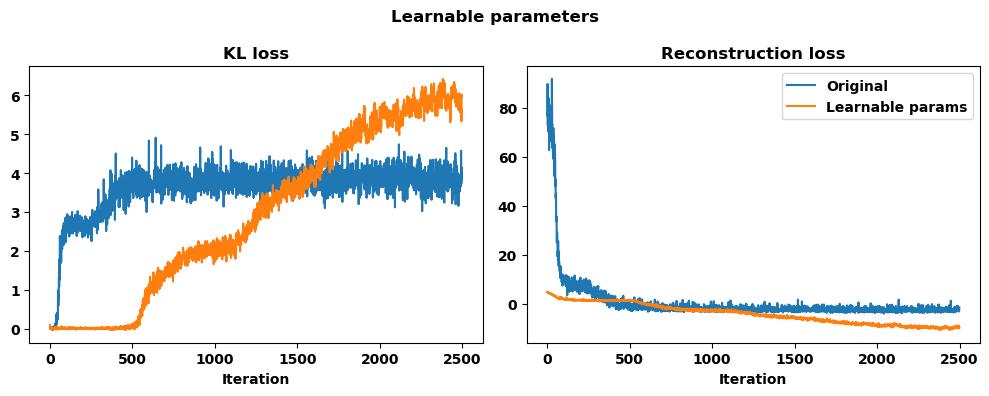

In [9]:
# Plotting!
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# KL loss
axs[0].plot(kl, label="Original")
axs[0].plot(kl1, label="Learnable params")
axs[0].set_title("KL loss")
axs[0].set_xlabel("Iteration")
# Reconstruction loss
axs[1].plot(recon, label="Original")
axs[1].plot(recon1, label="Learnable params")
axs[1].set_title("Reconstruction loss")
axs[1].set_xlabel("Iteration")
plt.tight_layout()
plt.suptitle("Learnable parameters")
plt.legend()
plt.tight_layout()

# Investigation 2: Sharing layers across $\mu$ and $\sigma^2$

### Model definitions

In [10]:
class iVAE_SharedLayers(nn.Module):
    def __init__(self, kx, ku, learnable_params=False):
        super().__init__()

        pz = 2  # dimensionality of latent space
        self.learn_flag = learnable_params

        # Prior p(z|u)
        if not self.learn_flag:
            self.mu_prior = torch.zeros(pz)
            self.prior_logvar = MLP(ku, pz, mu_flag=False)
        else:
            self.prior = MLP(ku, pz)

        # Encoder q(z|x,u)
        self.encoder = MLP(kx + ku, pz)
        
        # Decoder p(x|z)
        if not self.learn_flag:
            self.decoder_mu = MLP(pz, kx, var_flag=False)
            noise = torch.tensor(0.01)
            self.logvar_p = noise.log() * torch.ones(kx)
        else:
            self.decoder = MLP(pz, kx)

    def forward(self, x, u):
        xu = torch.cat((x, u), 1)
        # Prior parameters
        if self.learn_flag:
            self.mu_prior, self.logvar_prior = self.prior(u)
        else:
            self.logvar_prior = self.prior_logvar(u)

        # Encoder parameters
        self.mu_q, self.logvar_q = self.encoder(xu)

        # Reparameterization trick
        z = util.sample(self.mu_q, self.logvar_q)
        self.z = z

        # Decoder parameters
        if self.learn_flag:
            self.mu_p, self.logvar_p = self.decoder(z)
        else:
            self.mu_p = self.decoder_mu(z)

        return self.mu_p, self.logvar_p, self.mu_prior, self.logvar_prior, self.mu_q, self.logvar_q

    def loss(self, x):
        mu_prior = self.mu_prior.expand(x.shape[0], -1)
        px_z = util.normal_ll(x, self.mu_p.to(device), self.logvar_p.to(device))          # log p(x|z)
        qz_xu = util.normal_ll(self.z, self.mu_q.to(device), self.logvar_q.to(device))    # log p(z|x,u)
        pz_u = util.normal_ll(self.z, mu_prior.to(device), self.logvar_prior.to(device))  # log p(z|u)
        return px_z.mean(), qz_xu.mean(), pz_u.mean()

    def get_z_samples(self):
        return self.z

In [11]:
# Fix prior and decoder parameters
model2a = iVAE_SharedLayers(kx, ku, learnable_params=False).to(device)
optimizer2a = torch.optim.Adam(params=model2a.parameters(), lr=cfg['lr'])
util.get_num_parameters(model2a)

recon2a, kl2a, metrics2a = util.train_ivae(model2a, optimizer2a, train_loader, device, **cfg)

# Learn all parameters
model2b = iVAE_SharedLayers(kx, ku, learnable_params=True).to(device)
optimizer2b = torch.optim.Adam(params=model2b.parameters(), lr=cfg['lr'])
util.get_num_parameters(model2b)

recon2b, kl2b, metrics2b = util.train_ivae(model2b, optimizer2b, train_loader, device, **cfg)

Number of parameters: 12610


100%|██████████| 5/5 [00:09<00:00,  1.88s/it]


Number of parameters: 12916


100%|██████████| 5/5 [00:09<00:00,  1.91s/it]


### Plot training loss

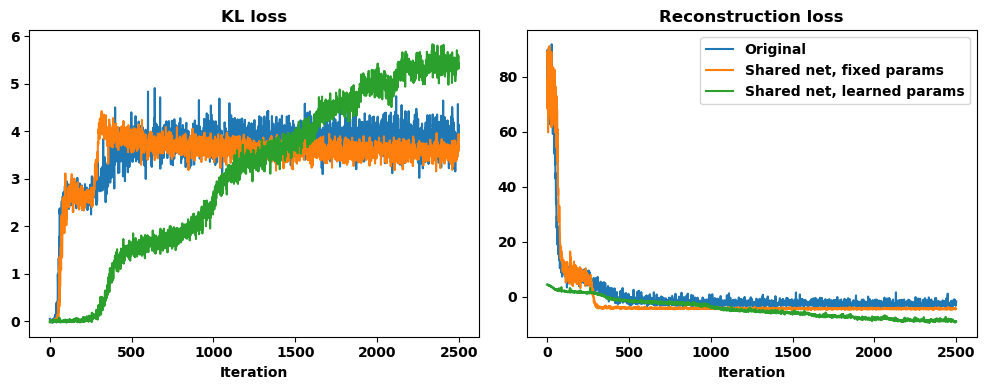

In [12]:
# Plotting!
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# KL loss
axs[0].plot(kl, label="Original")
axs[0].plot(kl2a, label="Shared net, fixed params")
axs[0].plot(kl2b, label="Shared net, learned params")
axs[0].set_title("KL loss")
axs[0].set_xlabel("Iteration")
# Reconstruction loss
axs[1].plot(recon, label="Original")
axs[1].plot(recon2a, label="Shared net, fixed params")
axs[1].plot(recon2b, label="Shared net, learned params")
axs[1].set_title("Reconstruction loss")
axs[1].set_xlabel("Iteration")
plt.legend()
plt.tight_layout()

# Investigation 3: Activation function

### Model definitions & training

In [13]:
# Model 3a: leaky relu with slope 1
model3a = iVAE_Base(kx, ku, **{'activation': 'leakyrelu', 'slope': 1}).to(device)
optimizer3a = torch.optim.Adam(params=model3a.parameters(), lr=cfg['lr'])
util.get_num_parameters(model3a)

recon3a, kl3a, metrics3a = util.train_ivae(model3a, optimizer3a, train_loader, device, **cfg)

Number of parameters: 17410


100%|██████████| 5/5 [00:09<00:00,  1.97s/it]


In [14]:
# Model 3b: relu
model3b = iVAE_Base(kx, ku, **{'activation': 'relu'}).to(device)
optimizer3b = torch.optim.Adam(params=model3b.parameters(), lr=cfg['lr'])
util.get_num_parameters(model3b)

recon3b, kl3b, metrics3b = util.train_ivae(model3b, optimizer3b, train_loader, device, **cfg)

Number of parameters: 17410


100%|██████████| 5/5 [00:09<00:00,  1.99s/it]


In [15]:
# Model 3c: tanh
model3c = iVAE_Base(kx, ku, **{'activation': 'tanh'}).to(device)
optimizer3c = torch.optim.Adam(params=model3c.parameters(), lr=cfg['lr'])
util.get_num_parameters(model3c)

recon3c, kl3c, metrics3c = util.train_ivae(model3c, optimizer3c, train_loader, device, **cfg)

Number of parameters: 17410


100%|██████████| 5/5 [00:09<00:00,  1.99s/it]


In [16]:
# Model 3d: sigmoid
model3d = iVAE_Base(kx, ku, **{'activation': 'sigmoid'}).to(device)
optimizer3d = torch.optim.Adam(params=model3d.parameters(), lr=cfg['lr'])
util.get_num_parameters(model3d)

recon3d, kl3d, metrics3d = util.train_ivae(model3d, optimizer3d, train_loader, device, **cfg)

Number of parameters: 17410


100%|██████████| 5/5 [00:10<00:00,  2.05s/it]


### Plot training loss

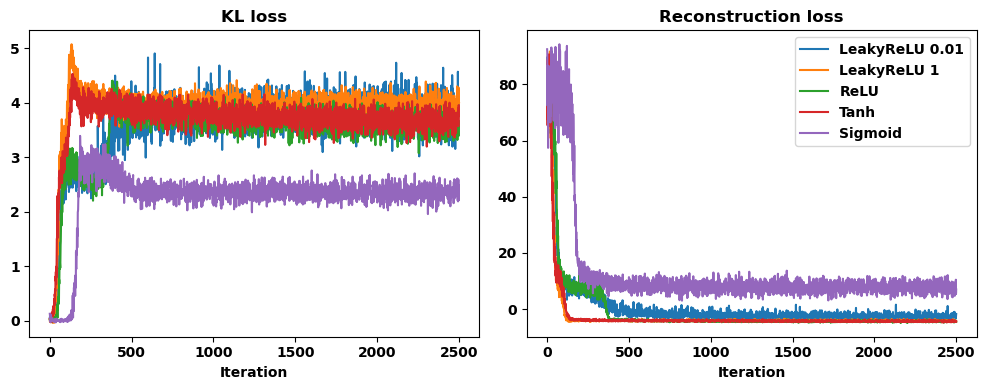

In [17]:
# Plotting!
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# KL loss
axs[0].plot(kl, label="LeakyReLU 0.01")
axs[0].plot(kl3a, label="LeakyReLU 1")
axs[0].plot(kl3b, label="ReLU")
axs[0].plot(kl3c, label="Tanh")
axs[0].plot(kl3d, label="Sigmoid")
axs[0].set_title("KL loss")
axs[0].set_xlabel("Iteration")
# Reconstruction loss
axs[1].plot(recon, label="LeakyReLU 0.01")
axs[1].plot(recon3a, label="LeakyReLU 1")
axs[1].plot(recon3b, label="ReLU")
axs[1].plot(recon3c, label="Tanh")
axs[1].plot(recon3d, label="Sigmoid")
axs[1].set_title("Reconstruction loss")
axs[1].set_xlabel("Iteration")
plt.legend()
plt.tight_layout()

# Investigation 4: The hidden layer

### Model definitions

In [18]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, mu_flag=True, var_flag=True, **kwargs):
        super().__init__()
        self.mu_flag = mu_flag
        self.var_flag = var_flag

        activation = kwargs.get('activation', 'leaky_relu')
        slope = kwargs.get('slope', 1e-2)
        hidden = kwargs.get('hidden_dim', 50)
        num_layers = kwargs.get('num_layers', 2)  # number of (linear, activation) blocks before output

        hidden_dims = num_layers * [hidden]
        hidden_dims = [in_dim] + hidden_dims

        layer_lst = []
        for n in range(num_layers):
            layer_lst.append(nn.Linear(hidden_dims[n], hidden_dims[n+1]))
            if activation == 'leaky_relu':
                layer_lst.append(nn.LeakyReLU(slope))
            elif activation == 'relu':
                layer_lst.append(nn.ReLU())
            elif activation == 'tanh':
                layer_lst.append(nn.Tanh())
            elif activation == 'sigmoid':
                layer_lst.append(nn.Sigmoid())

        self.layers = nn.Sequential(*layer_lst)
        if self.mu_flag:
            self.mu = nn.Linear(hidden_dims[-1], out_dim)
        if self.var_flag:
            self.log_var = nn.Linear(hidden_dims[-1], out_dim)

    def forward(self, x):
        out = self.layers(x)
        if self.mu_flag and self.var_flag:
            return self.mu(out), self.log_var(out)
        if self.mu_flag:
            return self.mu(out)
        if self.var_flag:
            return self.log_var(out)

## 4a: Dimension of hidden layer

In [19]:
hidden_dims = [2, 4, 25, 50, 100]
n_iters = len(hidden_dims)

recon_loss, kl_loss, metrics_arr = [], [], []

for h in range(n_iters):
    print("Hidden dim = " + str(hidden_dims[h]))
    
    mdl = iVAE_Base(kx, ku, **{'hidden_dim': hidden_dims[h]}).to(device)
    opt = torch.optim.Adam(params=mdl.parameters(), lr=cfg['lr'])
    recon, kl, metrics = util.train_ivae(mdl, opt, train_loader, device, **cfg)

    recon_loss.append(recon)
    kl_loss.append(kl)
    metrics_arr.append(metrics)

Hidden dim = 2


100%|██████████| 5/5 [00:09<00:00,  1.82s/it]


Hidden dim = 4


100%|██████████| 5/5 [00:09<00:00,  1.94s/it]


Hidden dim = 25


100%|██████████| 5/5 [00:10<00:00,  2.02s/it]


Hidden dim = 50


100%|██████████| 5/5 [00:09<00:00,  1.99s/it]


Hidden dim = 100


100%|██████████| 5/5 [00:09<00:00,  1.95s/it]


### Plot training loss

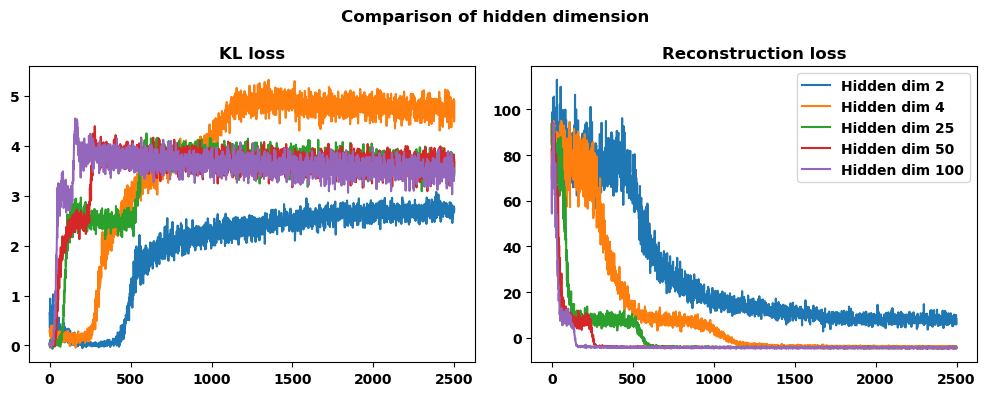

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for h in range(n_iters):
    axs[0].plot(kl_loss[h], label="Hidden dim " + str(hidden_dims[h]))
    axs[1].plot(recon_loss[h], label="Hidden dim " + str(hidden_dims[h]))
axs[0].set_title("KL loss")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.suptitle("Comparison of hidden dimension")
plt.tight_layout()

## 4b: Number of hidden layers

In [21]:
layers_lst = [1, 2, 3, 5, 10]
n_iters = len(layers_lst)

recon_loss_layers, kl_loss_layers, metrics_arr = [], [], []

for l in range(n_iters):
    print("# hidden layers = " + str(layers_lst[l]))
    
    mdl = iVAE_Base(kx, ku, **{'num_layers': layers_lst[l]}).to(device)
    opt = torch.optim.Adam(params=mdl.parameters(), lr=cfg['lr'])
    recon, kl, metrics = util.train_ivae(mdl, opt, train_loader, device, **cfg)

    recon_loss_layers.append(recon)
    kl_loss_layers.append(kl)
    metrics_arr.append(metrics)

# hidden layers = 1


100%|██████████| 5/5 [00:08<00:00,  1.74s/it]


# hidden layers = 2


100%|██████████| 5/5 [00:10<00:00,  2.08s/it]


# hidden layers = 3


100%|██████████| 5/5 [00:10<00:00,  2.16s/it]


# hidden layers = 5


100%|██████████| 5/5 [00:12<00:00,  2.58s/it]


# hidden layers = 10


100%|██████████| 5/5 [00:19<00:00,  3.83s/it]


### Plot training loss

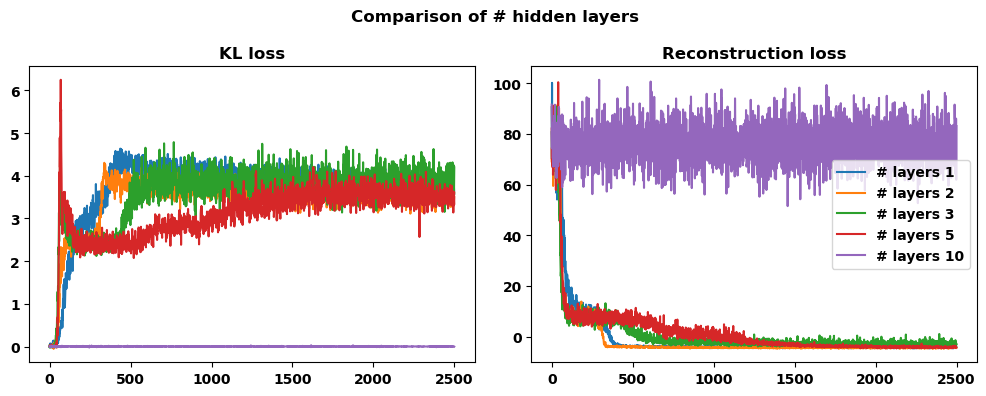

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for l in range(n_iters):
    axs[0].plot(kl_loss_layers[l], label="# layers " + str(layers_lst[l]))
    axs[1].plot(recon_loss_layers[l], label="# layers " + str(layers_lst[l]))
axs[0].set_title("KL loss")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.suptitle("Comparison of # hidden layers")
plt.tight_layout()